In [1]:
!pip install kagglehub

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import kagglehub

In [2]:
path = kagglehub.dataset_download(
    "sabahesaraki/breast-ultrasound-images-dataset"
)

DATASET_PATH = os.path.join(path, "Dataset_BUSI_with_GT")

print("Dataset Path:", DATASET_PATH)

100%|██████████| 195M/195M [00:15<00:00, 13.0MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/sabahesaraki/breast-ultrasound-images-dataset/versions/1/Dataset_BUSI_with_GT


In [3]:
classes = ["benign","malignant","normal"]

IMG_SIZE = 128

images = []
labels = []

for cls in classes:

    folder = os.path.join(DATASET_PATH, cls)

    for file in os.listdir(folder):

        if "_mask" in file:
            continue

        img_path = os.path.join(folder, file)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        img = np.stack([img,img,img], axis=-1)

        images.append(img)
        labels.append(cls)

X = np.array(images)
y = np.array(labels)

print("Dataset Shape:", X.shape)

Dataset Shape: (780, 128, 128, 3)


In [4]:
le = LabelEncoder()
y = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['benign' 'malignant' 'normal']


In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (546, 128, 128, 3)
Val: (117, 128, 128, 3)
Test: (117, 128, 128, 3)


In [6]:
X_train = torch.tensor(X_train, dtype=torch.float32).permute(0,3,1,2)
X_val = torch.tensor(X_val, dtype=torch.float32).permute(0,3,1,2)
X_test = torch.tensor(X_test, dtype=torch.float32).permute(0,3,1,2)

y_train = torch.tensor(y_train)
y_val = torch.tensor(y_val)
y_test = torch.tensor(y_test)

In [7]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=16)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=16)

In [8]:
class DepthwisePointwiseBlock(nn.Module):

    def __init__(self, in_c, out_c, stride=1):
        super().__init__()

        self.depthwise = nn.Conv2d(
            in_c, in_c, kernel_size=3, stride=stride,
            padding=1, groups=in_c
        )

        self.bn1 = nn.BatchNorm2d(in_c)

        self.pointwise = nn.Conv2d(
            in_c, out_c, kernel_size=1
        )

        self.bn2 = nn.BatchNorm2d(out_c)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.depthwise(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.pointwise(x)
        x = self.bn2(x)
        x = self.relu(x)

        return x

In [9]:
class CustomMobileNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.init = nn.Sequential(
            nn.Conv2d(3,32,3,2,1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.b1 = DepthwisePointwiseBlock(32,64)
        self.b2 = DepthwisePointwiseBlock(64,128,2)
        self.b3 = DepthwisePointwiseBlock(128,128)

        self.b4 = DepthwisePointwiseBlock(128,256,2)
        self.b5 = DepthwisePointwiseBlock(256,256)

        self.b6 = DepthwisePointwiseBlock(256,512,2)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,3)
        )

    def forward(self,x):

        x = self.init(x)

        x = self.b1(x)
        x = self.b2(x)
        x = self.b3(x)

        x = self.b4(x)
        x = self.b5(x)

        x = self.b6(x)

        x = self.pool(x)
        x = x.view(x.size(0),-1)

        return self.fc(x)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CustomMobileNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [11]:
epochs = 50

for epoch in range(epochs):

    model.train()
    loss_sum = 0

    for images,labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        loss_sum += loss.item()

    print(f"Epoch {epoch+1}, Loss: {loss_sum}")

Epoch 1, Loss: 34.58473592996597
Epoch 2, Loss: 33.06849479675293
Epoch 3, Loss: 31.424958765506744
Epoch 4, Loss: 30.809581518173218
Epoch 5, Loss: 29.9619203209877
Epoch 6, Loss: 29.45540028810501
Epoch 7, Loss: 27.88843834400177
Epoch 8, Loss: 27.53148853778839
Epoch 9, Loss: 26.20703834295273
Epoch 10, Loss: 23.365306109189987
Epoch 11, Loss: 19.19745421409607
Epoch 12, Loss: 15.957129299640656
Epoch 13, Loss: 13.010581642389297
Epoch 14, Loss: 10.396994546055794
Epoch 15, Loss: 7.94316741079092
Epoch 16, Loss: 6.556704044342041
Epoch 17, Loss: 5.603103615343571
Epoch 18, Loss: 4.505939196795225
Epoch 19, Loss: 3.7555178329348564
Epoch 20, Loss: 4.401410110294819
Epoch 21, Loss: 2.431252706795931
Epoch 22, Loss: 2.2976790834218264
Epoch 23, Loss: 2.394511390477419
Epoch 24, Loss: 2.1301691066473722
Epoch 25, Loss: 5.8055959874764085
Epoch 26, Loss: 2.5361735029146075
Epoch 27, Loss: 1.4264444867148995
Epoch 28, Loss: 1.0674225254915655
Epoch 29, Loss: 0.9476700788363814
Epoch 30, L

In [12]:
y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images,labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _,preds = torch.max(outputs,1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

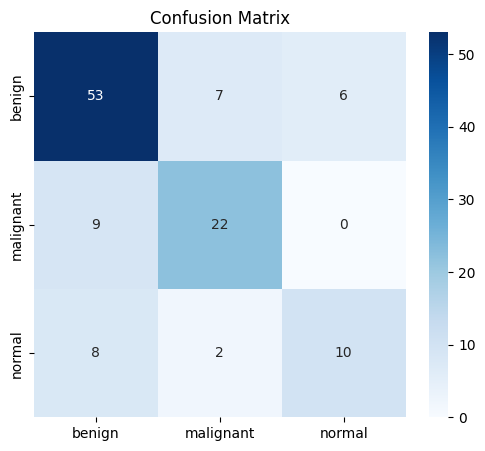

In [13]:
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("Confusion Matrix")
plt.show()

In [14]:
print(classification_report(y_true,y_pred,target_names=le.classes_))

              precision    recall  f1-score   support

      benign       0.76      0.80      0.78        66
   malignant       0.71      0.71      0.71        31
      normal       0.62      0.50      0.56        20

    accuracy                           0.73       117
   macro avg       0.70      0.67      0.68       117
weighted avg       0.72      0.73      0.72       117



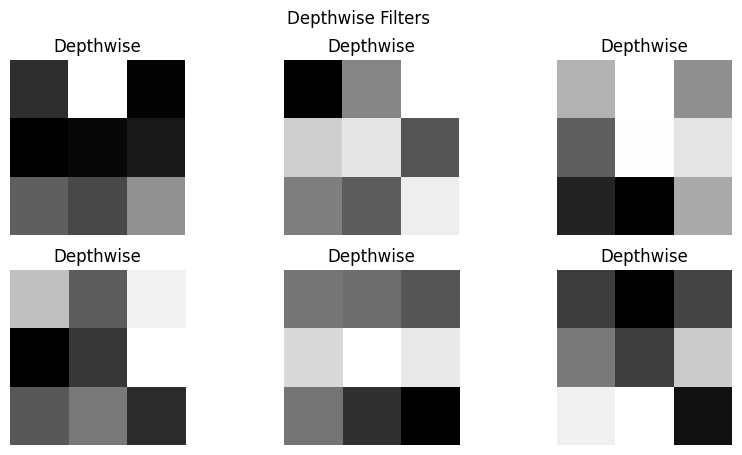

In [15]:
layer = model.b1.depthwise

weights = layer.weight.detach().cpu().numpy()

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(weights[i][0], cmap="gray")
    plt.title("Depthwise")
    plt.axis("off")

plt.suptitle("Depthwise Filters")
plt.show()

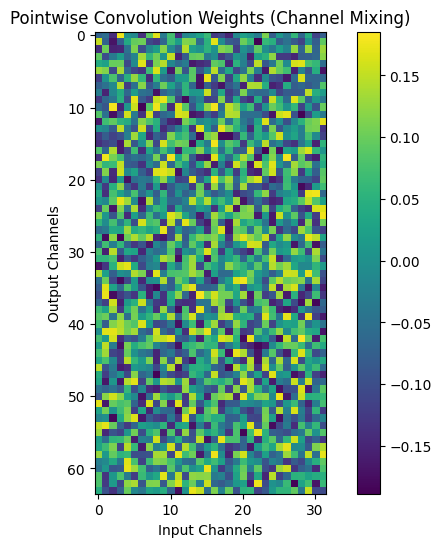

In [16]:
layer = model.b1.pointwise

weights = layer.weight.detach().cpu().numpy()

# reshape to (out_channels, in_channels)
weights = weights.reshape(weights.shape[0], -1)

plt.figure(figsize=(8,6))

plt.imshow(weights, cmap="viridis")
plt.colorbar()

plt.title("Pointwise Convolution Weights (Channel Mixing)")
plt.xlabel("Input Channels")
plt.ylabel("Output Channels")

plt.show()

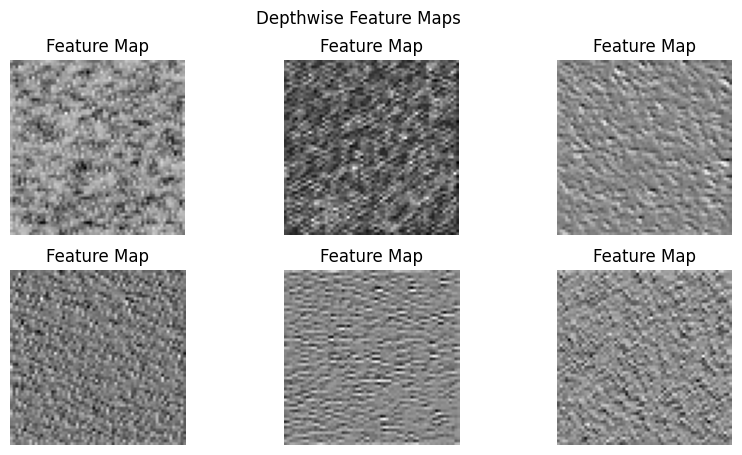

In [17]:
x = torch.randn(1,3,128,128).to(device)

with torch.no_grad():
    x_processed = model.init(x)
    out = model.b1.depthwise(x_processed)

feature = out[0].cpu().numpy()

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(feature[i], cmap="gray")
    plt.title("Feature Map")
    plt.axis("off")

plt.suptitle("Depthwise Feature Maps")
plt.show()

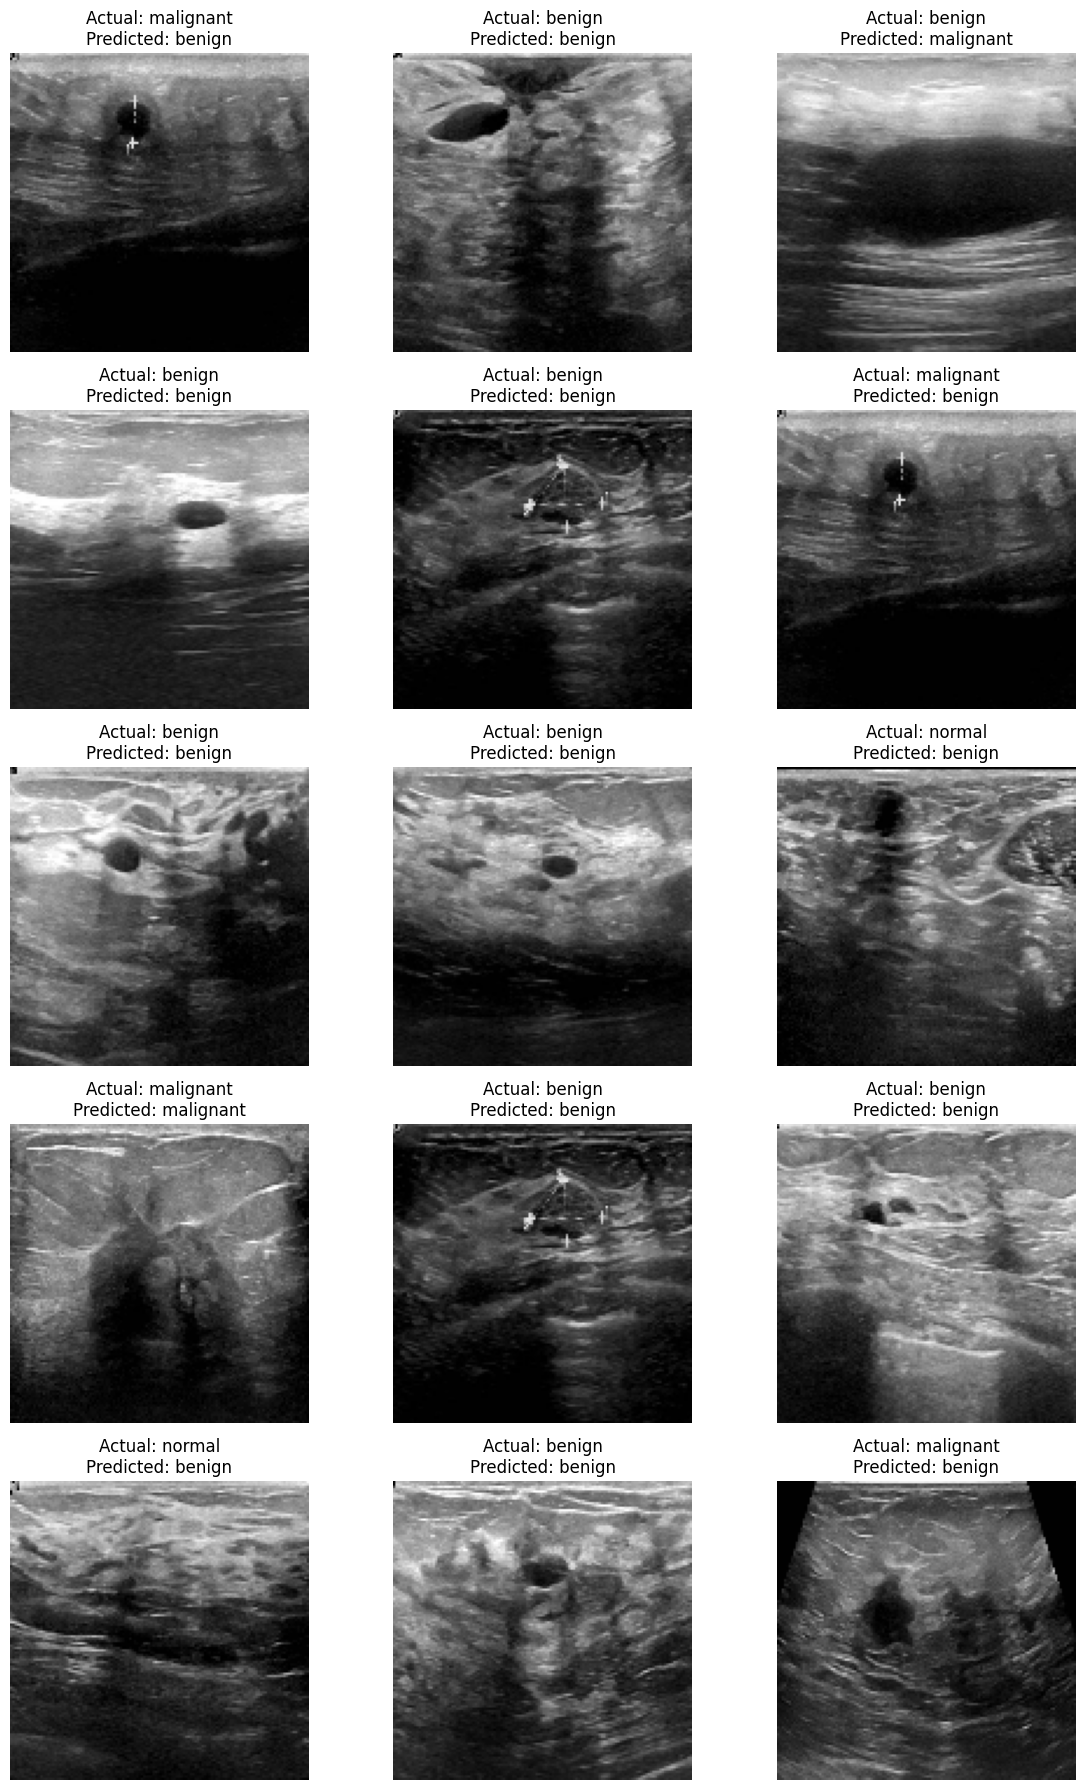

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import torch

num_images = 15

# Random indices from test set
indices = np.random.choice(len(X_test), num_images)

sample_images = X_test[indices]
sample_labels = y_test[indices]

model.eval()

pred_classes = []

with torch.no_grad():

    inputs = sample_images.to(device)

    outputs = model(inputs)

    _, preds = torch.max(outputs, 1)

    pred_classes = preds.cpu().numpy()

# Plot
plt.figure(figsize=(12,18))

for i in range(num_images):

    ax = plt.subplot(5,3,i+1)
    ax.axis("off")

    actual = le.classes_[sample_labels[i].item()]
    predicted = le.classes_[pred_classes[i]]

    ax.set_title(f"Actual: {actual}\nPredicted: {predicted}")

    # Convert tensor → image
    img = sample_images[i].permute(1,2,0).cpu().numpy()

    plt.imshow(img)

plt.tight_layout()
plt.show()

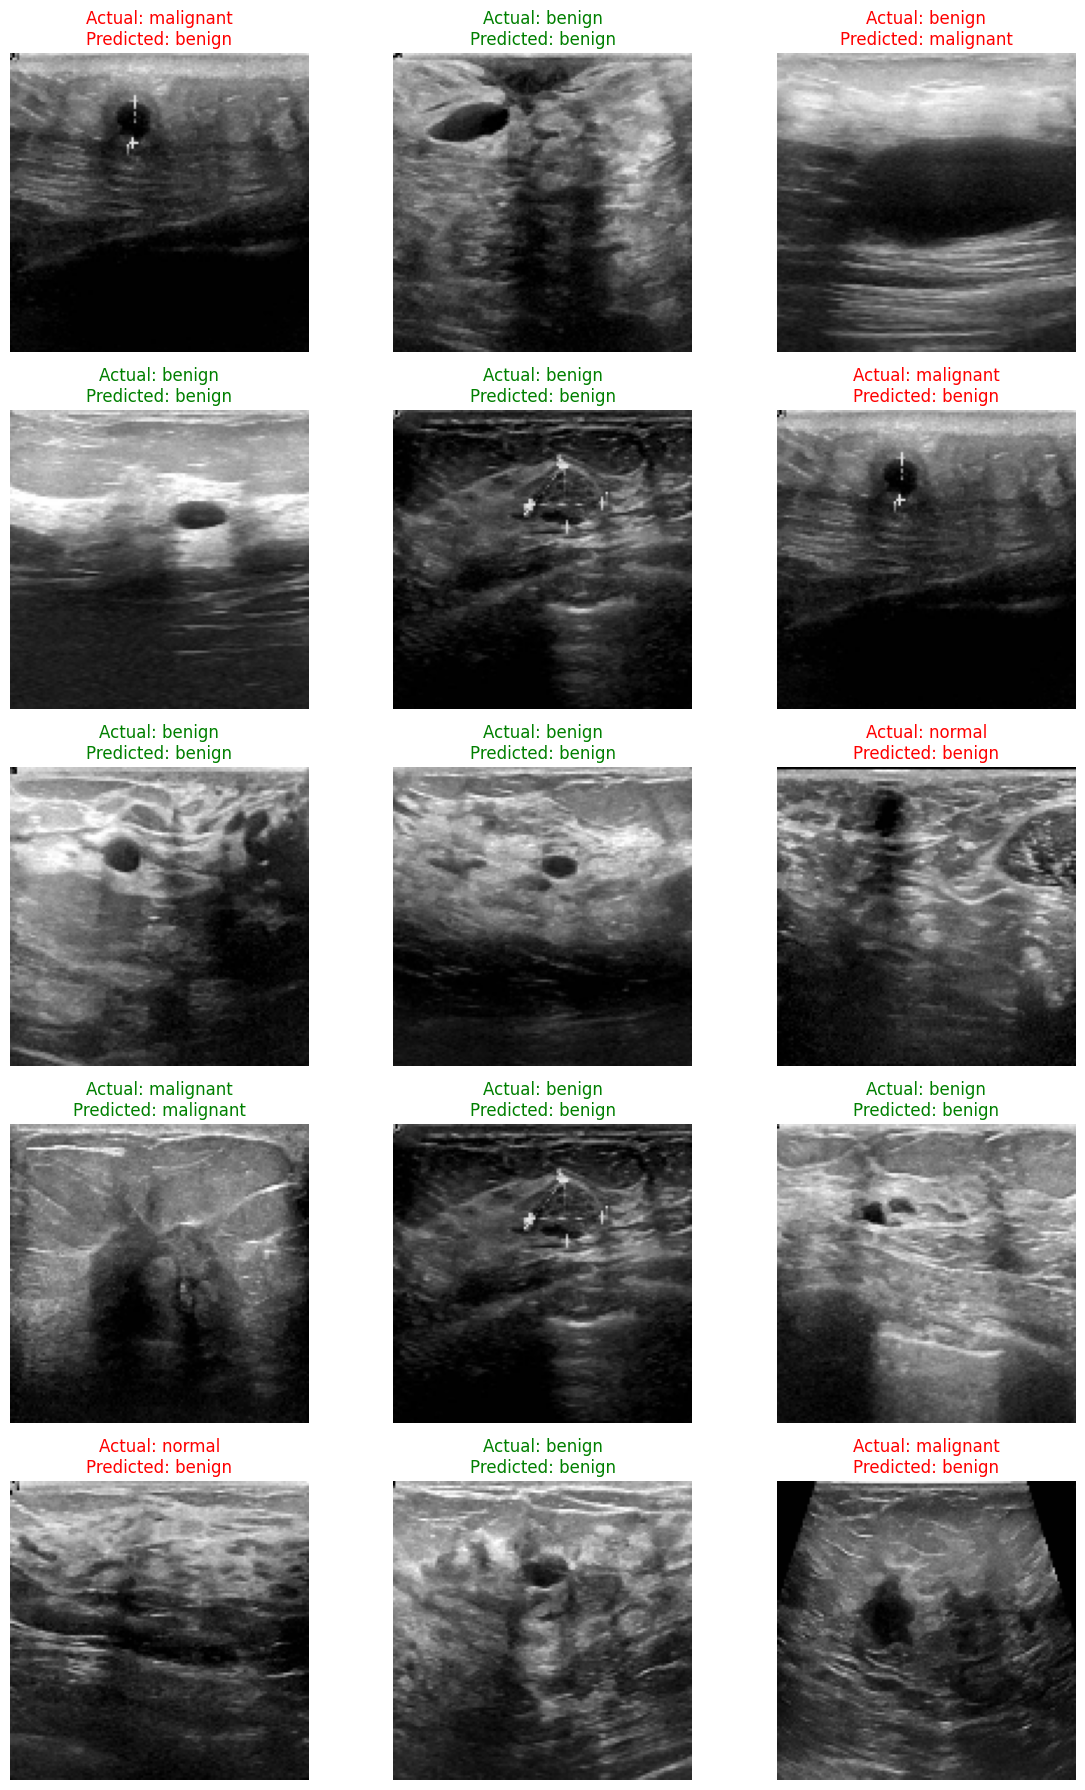

In [19]:
plt.figure(figsize=(12,18))

for i in range(num_images):

    ax = plt.subplot(5,3,i+1)
    ax.axis("off")

    actual = le.classes_[sample_labels[i].item()]
    predicted = le.classes_[pred_classes[i]]

    color = "green" if actual == predicted else "red"

    ax.set_title(
        f"Actual: {actual}\nPredicted: {predicted}",
        color=color
    )

    img = sample_images[i].permute(1,2,0).cpu().numpy()

    plt.imshow(img)

plt.tight_layout()
plt.show()